In [54]:
# Библиотеки
import math
import matplotlib.pyplot as plt

In [ ]:
# Правая часть системы
# x  - текущий аргумент
# y1 - текущее значение функции y
# y2 - текущее значение производной y'
def f_system(x, y1, y2):
    # Первое уравнение: y1' = y2
    dy1 = y2

    # Второе уравнение получаем из исходного:
    # y'' + y' + y = 3x^2 - x - 1
    # => y'' = 3x^2 - x - 1 - y' - y
    # => dy2 = 3x^2 - x - 1 - y2 - y1
    dy2 = 3 * x**2 - x - 1 - y2 - y1

    return dy1, dy2


In [56]:
# Метод Рунге-Кутты 4ого порядка
# x0 - начало отрезка
# y10 - начальное значение y(0)
# y20 - начальное значение y'(0)
# x_end - конец отрезка
# h - шаг интегрирования
def rk4_second_order(x0, y10, y20, x_end, h):
    # Списки для накопления результатов.
    xs = [x0] # точки по x
    y1s = [y10] # значения y
    y2s = [y20] # значения y'

    # Текущие значения.
    x = x0
    y1 = y10
    y2 = y20

    # Количество шагов.
    n = int(round((x_end - x0) / h))

    for _ in range(n):
        # k1 - наклон в начале шага
        k1y1, k1y2 = f_system(x, y1, y2)

        # k2 - оценка в середине шага с учетом k1
        k2y1, k2y2 = f_system(
            x + h / 2,
            y1 + h * k1y1 / 2,
            y2 + h * k1y2 / 2
        )

        # k3 - еще одна оценка в середине шага с учетом k2
        k3y1, k3y2 = f_system(
            x + h / 2,
            y1 + h * k2y1 / 2,
            y2 + h * k2y2 / 2
        )

        # k4 - наклон в конце шага
        k4y1, k4y2 = f_system(
            x + h,
            y1 + h * k3y1,
            y2 + h * k3y2
        )

        # Основная формула RK4
        y1 += h * (k1y1 + 2 * k2y1 + 2 * k3y1 + k4y1) / 6
        y2 += h * (k1y2 + 2 * k2y2 + 2 * k3y2 + k4y2) / 6
        x += h

        # Сохраняем результаты шага
        xs.append(x)
        y1s.append(y1)
        y2s.append(y2)

    return xs, y1s, y2s


In [57]:
steps = [0.1, 0.01, 0.001]
results = {}

# Запускаем метод для каждого шага
for h in steps:
    xs, ys, zs = rk4_second_order(0.0, -0.9, 3.2, 1.0, h)
    results[h] = (xs, ys, zs)

    # Вывод конечных значений
    print(f"h = {h}: y(1) = {ys[-1]:.10f}, y'(1) = {zs[-1]:.10f}")


h = 0.1: y(1) = 0.8480435309, y'(1) = 0.7673227084
h = 0.01: y(1) = 0.8480432521, y'(1) = 0.7673246498
h = 0.001: y(1) = 0.8480432521, y'(1) = 0.7673246500


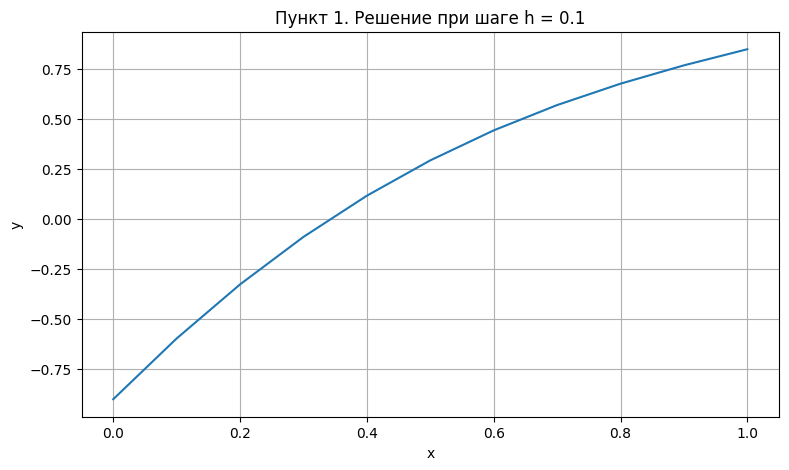

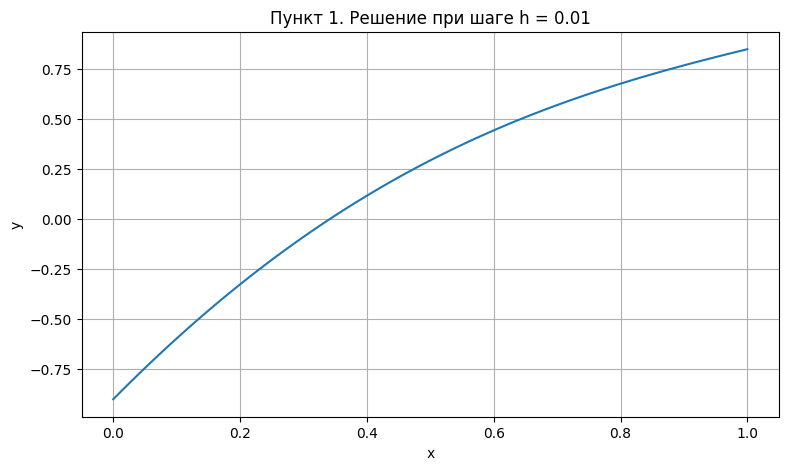

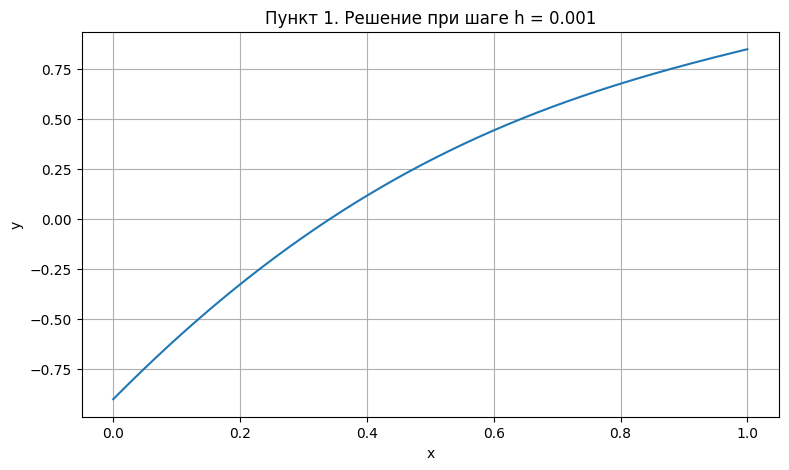

In [ ]:
# Отдельный график для каждого шага
for h in steps:
    xs, ys, _ = results[h]

    plt.figure(figsize=(9, 5))
    plt.plot(xs, ys)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Пункт 1. Решение при шаге h = {h}')
    plt.grid(True)
    plt.show()

Сравнение скорости сходимости по конечным значениям y(1):
|y_0.1(1)  - y_0.01(1)|  = 2.78766e-07
|y_0.01(1) - y_0.001(1)| = 7.45282e-12
Отношение delta_1 / delta_2 = 37404.093477


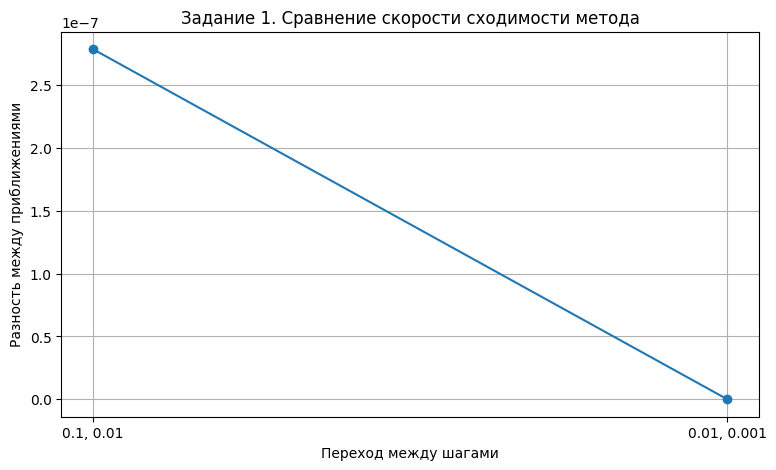

При уменьшении шага разность между соседними решениями уменьшается, следовательно, численное решение сходится


In [59]:
# Сравнение скорости сходимости метода
# Конечные значения решения в точке x = 1
y_h_01 = results[0.1][1][-1]
y_h_001 = results[0.01][1][-1]
y_h_0001 = results[0.001][1][-1]

# Разности между соседними приближениями
delta_1 = abs(y_h_01 - y_h_001)
delta_2 = abs(y_h_001 - y_h_0001)

print("Сравнение скорости сходимости по конечным значениям y(1):")
print(f"|y_0.1(1)  - y_0.01(1)|  = {delta_1:.6}")
print(f"|y_0.01(1) - y_0.001(1)| = {delta_2:.6}")

if delta_2 != 0:
    print(f"Отношение delta_1 / delta_2 = {delta_1 / delta_2:.6f}")
else:
    print("delta_2 = 0, отношение вычислить нельзя.")

# График сравнения скорости сходимости
pairs = ['0.1, 0.01', '0.01, 0.001']
deltas = [delta_1, delta_2]

plt.figure(figsize=(9, 5))
plt.plot(pairs, deltas, marker='o')
plt.xlabel('Переход между шагами')
plt.ylabel('Разность между приближениями')
plt.title('Задание 1. Сравнение скорости сходимости метода')
plt.grid(True)
plt.show()

if delta_2 < delta_1:
    print("При уменьшении шага разность между соседними решениями уменьшается, следовательно, численное решение сходится")
else:
    print("Уменьшение шага не дало уменьшения разности между решениями, надо дополнительно проверить вычисления")

In [60]:
# Сравнение итоговых значений
for h in steps:
    xs, ys, zs = results[h]
    print(f'h = {h}: y(1) = {ys[-1]:.12f}')


h = 0.1: y(1) = 0.848043530891
h = 0.01: y(1) = 0.848043252125
h = 0.001: y(1) = 0.848043252117


In [61]:
# Правая часть уравнения y' = e^x - y
def f_adaptive(x, y):
    return math.exp(x) - y

# Один шаг метода Рунге–Кутты 4-го порядка для уравнения y' = f(x, y)
def rk4_step(f, x, y, h):
    # Четыре промежуточных коэффициента
    k1 = f(x, y)
    k2 = f(x + h / 2, y + h * k1 / 2)
    k3 = f(x + h / 2, y + h * k2 / 2)
    k4 = f(x + h, y + h * k3)

    # Формула перехода на следующий шаг
    return y + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6


In [62]:
# Реализация адаптивного шага
# f - функция правой части
# x0 - начало отрезка
# y0 - начальное значение
# x_end - конец отрезка
# h0 - начальный шаг
# tol - допустимая локальная погрешность
def adaptive_rk4(f, x0, y0, x_end, h0=0.1, tol=1e-6):
    x = x0
    y = y0
    h = h0

    xs = [x] # точки сетки
    ys = [y] # значения решения
    hs = [] # реально использованные шаги

    while x < x_end:
        # Если шаг выходит за конец отрезка, уменьшаем его так, чтобы точно попасть в x_end
        if x + h > x_end:
            h = x_end - x

        # Один полный шаг длины h
        y_big = rk4_step(f, x, y, h)

        # Два половинных шага длины h/2
        y_half = rk4_step(f, x, y, h / 2)
        y_small = rk4_step(f, x + h / 2, y_half, h / 2)

        # Оценка локальной погрешности.
        # Для RK4 используем деление на 15
        err = abs(y_small - y_big) / 15.0

        # Если ошибка допустима, шаг принимаем
        if err <= tol:
            x += h
            y = y_small

            xs.append(x)
            ys.append(y)
            hs.append(h)

            # После успешного шага можно изменить размер шага
            if err == 0:
                factor = 2.0
            else:
                factor = 0.9 * (tol / err) ** 0.2
                factor = min(2.0, max(0.5, factor))

            h *= factor

        # Если ошибка велика, шаг не принимаем, а только уменьшаем и пробуем снова
        else:
            factor = 0.9 * (tol / err) ** 0.2
            factor = max(0.1, min(0.5, factor))
            h *= factor

    return xs, ys, hs


In [63]:
# Работа адаптивного метода
xs_ad, ys_ad, hs_ad = adaptive_rk4(f_adaptive, 0.0, 1.0, 1.0, h0=0.1, tol=1e-6)

print(f'Приближенное значение y(1) = {ys_ad[-1]:.10f}')
print(f'Количество принятых шагов = {len(hs_ad)}')


Приближенное значение y(1) = 1.5430823672
Количество принятых шагов = 6


In [64]:
# Использованные шаги
for i, step in enumerate(hs_ad, start=1):
    print(f'Шаг {i}: h = {step:.8f}')

Шаг 1: h = 0.10000000
Шаг 2: h = 0.20000000
Шаг 3: h = 0.23601899
Шаг 4: h = 0.23102220
Шаг 5: h = 0.22403305
Шаг 6: h = 0.00892575


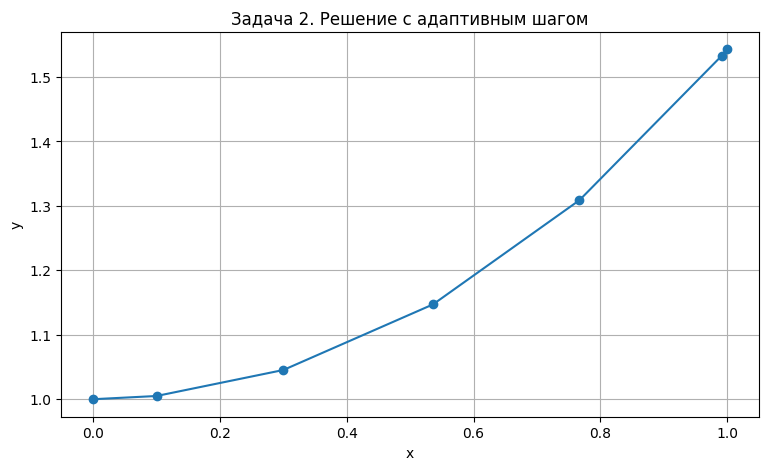

In [65]:
# График решения
plt.figure(figsize=(9, 5))
plt.plot(xs_ad, ys_ad, marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Задача 2. Решение с адаптивным шагом')
plt.grid(True)
plt.show()


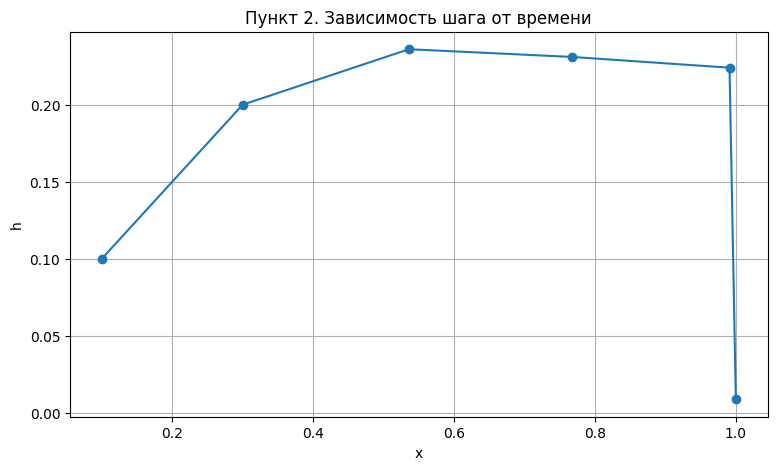

In [66]:
# График зависимости шага от времени
plt.figure(figsize=(9, 5))

# По оси x берём точки, в которых шаг уже принят
plt.plot(xs_ad[1:], hs_ad, marker='o')

plt.xlabel('x')
plt.ylabel('h')
plt.title('Пункт 2. Зависимость шага от времени')
plt.grid(True)
plt.show()
